# Notebook 03 — Preprocessing + Sentiment Analysis
**Owner:** Person 3

**Input:** `../data/reddit/reddit_raw.csv` (from Notebook 02)

**Goal:** Clean Reddit text, score sentiment per post using VADER, and aggregate to a weekly sentiment index.

**Output:** `../data/processed/sentiment_weekly.csv`

**Columns:** `week | subreddit | avg_sentiment | post_count | avg_upvotes`

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import re
import nltk
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nlp = spacy.load('en_core_web_sm')
vader = SentimentIntensityAnalyzer()

## 1. Load Reddit Data

In [2]:
df = pd.read_csv("../data/reddit/reddit_raw.csv", parse_dates=["date"])
print(f"Loaded {len(df)} posts")
print(df["subreddit"].value_counts())
df.head()

Loaded 2377 posts
subreddit
buildapc        1477
pcmasterrace     821
hardware          79
Name: count, dtype: int64


,post_id,date,subreddit,title,body,top_comments,upvotes,url
0,1kq5v8d,2025-05-19,buildapc,Help me upgrade my sisters PC,My sister made the very humble wish for her bi...,NaN,1,https://reddit.com/r/buildapc/comments/1kq5v8d...
1,1kq5uo9,2025-05-19,buildapc,Is Corsair CX 550 ( 2023 VERSION ) a good qual...,"Hello, I have a few questions regarding this p...",It's a D tier on the SPL tier list. D criter...,1,https://reddit.com/r/buildapc/comments/1kq5uo9...
2,1kq0tku,2025-05-19,buildapc,gpu for 1080p gaming $600 price range,"I'm looking to upgrade my GPU, a 1080 Ti that'...",You don't need to spend anywhere near $600 for...,1,https://reddit.com/r/buildapc/comments/1kq0tku...
3,1kpqqi6,2025-05-18,buildapc,Are these two builds comparable to a better-tr...,"To preface, I don't need a PC that can stream ...",They aren't equal. But one is not worth over $...,1,https://reddit.com/r/buildapc/comments/1kpqqi6...
4,1kpqa83,2025-05-18,buildapc,[Build Review] 7950X + RTX 4070 Ti SUPER white...,Goal \n\n* Heavy computational fluid dynamics...,Don't buy an RTX 4070 Ti Super. They haven't b...,1,https://reddit.com/r/buildapc/comments/1kpqa83...


## 2. Build Full Text Field
Combine title + body + top comments for richer sentiment signal.

In [3]:
def combine_text(row) -> str:
    parts = [
        str(row.get("title", "") or ""),
        str(row.get("body", "") or ""),
        str(row.get("top_comments", "") or "")
    ]
    return " ".join(parts)
df["full_text"] = df.apply(combine_text, axis=1)
print("Sample full text:")
print(df["full_text"].iloc[0][:300])

Sample full text:
Help me upgrade my sisters PC My sister made the very humble wish for her birthday simply for a recommendation of parts to upgrade her PC.

Her current specs are:

Core i5-6600

RTX 3060

250 GB SSD

8 GB of ram (yes)

Asus B150M-A motherboard

Corsair VS550 PSU

Her budget is actually rather solid,


## 3. Text Preprocessing

In [4]:
STOP_WORDS = set(stopwords.words('english'))
def preprocess(text: str) -> str:
    """Lowercase, remove URLs/special chars, lemmatize, remove stopwords."""
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    doc = nlp(text, disable=["ner", "parser"])
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in STOP_WORDS and len(token.lemma_) > 2
    ]
    return " ".join(tokens)
df["text_clean"] = df["full_text"].apply(preprocess)
print("Preprocessing done")
df[["full_text", "text_clean"]].head(2)

Preprocessing done


,full_text,text_clean
0,Help me upgrade my sisters PC My sister made t...,help upgrade sister sister make humble wish bi...
1,Is Corsair CX 550 ( 2023 VERSION ) a good qual...,corsair version good quality psu o...


## 4. Sentiment Scoring with VADER
VADER is designed for social media text — handles slang, caps, punctuation well.

We score on raw `full_text` (not preprocessed) — VADER relies on punctuation/capitalization for signal.

In [5]:
def score_sentiment(text: str) -> float:
    """Return VADER compound score: -1 (very negative) to +1 (very positive)."""
    return vader.polarity_scores(text)["compound"]
df["sentiment_score"] = df["full_text"].apply(score_sentiment)
def label(score):
    if score >= 0.05: return "positive"
    if score <= -0.05: return "negative"
    return "neutral"
df["sentiment_label"] = df["sentiment_score"].apply(label)
print(df["sentiment_label"].value_counts())
df[["title", "sentiment_score", "sentiment_label"]].head()

sentiment_label
positive    2022
negative     295
neutral       60
Name: count, dtype: int64


,title,sentiment_score,sentiment_label
0,Help me upgrade my sisters PC,0.9868,positive
1,Is Corsair CX 550 ( 2023 VERSION ) a good qual...,-0.9783,negative
2,gpu for 1080p gaming $600 price range,0.9073,positive
3,Are these two builds comparable to a better-tr...,0.9578,positive
4,[Build Review] 7950X + RTX 4070 Ti SUPER white...,0.9932,positive


## 5. Aggregate to Weekly Sentiment

In [6]:
df["week"] = df["date"].dt.to_period("W")
sentiment_weekly = (
    df.groupby(["week", "subreddit"])
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        post_count=("post_id", "count"),
        avg_upvotes=("upvotes", "mean")
    )
    .reset_index()
)
combined = (
    df.groupby("week")
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        post_count=("post_id", "count"),
        avg_upvotes=("upvotes", "mean")
    )
    .reset_index()
)
combined["subreddit"] = "ALL"
sentiment_weekly = pd.concat([sentiment_weekly,combined],ignore_index=True)
print(f"Weekly sentiment rows: {len(sentiment_weekly)}")
sentiment_weekly.head(10)

Weekly sentiment rows: 80


,week,subreddit,avg_sentiment,post_count,avg_upvotes
0,2024-09-30/2024-10-06,hardware,0.063600,2,1.0
1,2024-10-07/2024-10-13,hardware,-0.094712,8,1.0
2,2024-10-14/2024-10-20,hardware,0.980650,2,1.0
3,2024-10-21/2024-10-27,hardware,0.998600,1,1.0
4,2024-10-28/2024-11-03,hardware,0.428067,6,1.0
5,2024-11-04/2024-11-10,hardware,0.516400,3,1.0
6,2024-11-11/2024-11-17,hardware,0.123050,2,1.0
7,2024-11-18/2024-11-24,hardware,0.994300,1,1.0
8,2024-11-25/2024-12-01,hardware,0.969100,1,1.0
9,2024-12-02/2024-12-08,hardware,0.013450,2,1.0


## 6. Save Output

In [7]:
OUTPUT_PATH = Path("../data/processed/sentiment_weekly.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
sentiment_weekly.to_csv(OUTPUT_PATH,index=False)
print(f"Saved to {OUTPUT_PATH}")

Saved to ../data/processed/sentiment_weekly.csv


## 7. Quick Visualization

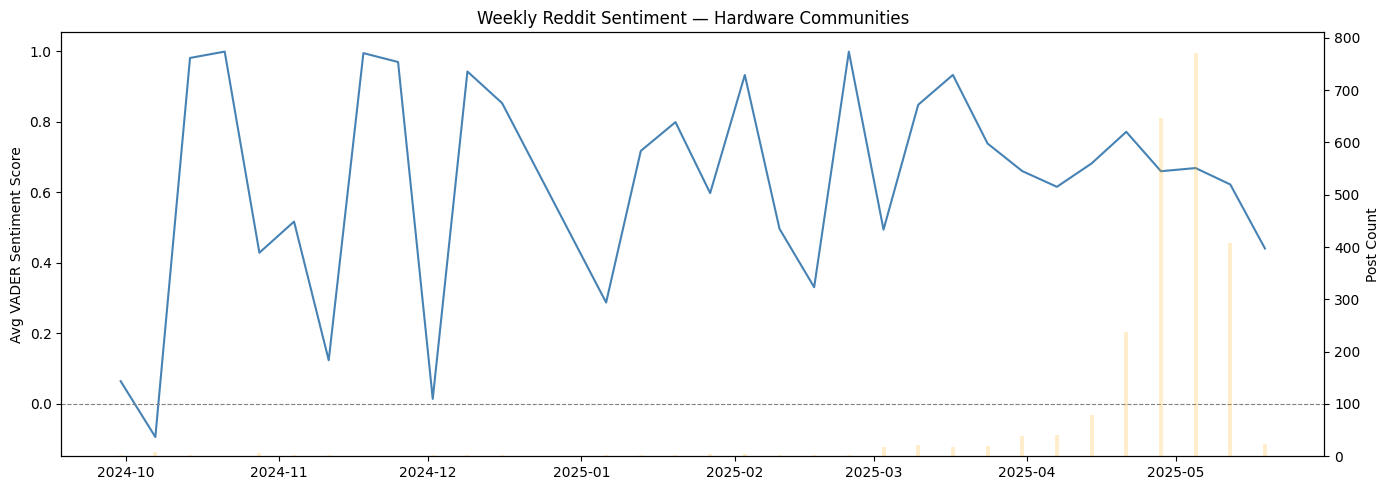

In [8]:
all_weekly = sentiment_weekly[sentiment_weekly["subreddit"] == "ALL"].copy()
all_weekly["week_dt"] = all_weekly["week"].dt.to_timestamp()
all_weekly = all_weekly.sort_values("week_dt")
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(all_weekly["week_dt"], all_weekly["avg_sentiment"],color="steelblue",label="Avg Sentiment")
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_ylabel("Avg VADER Sentiment Score")
ax1.set_title("Weekly Reddit Sentiment — Hardware Communities")
ax2 = ax1.twinx()
ax2.bar(all_weekly["week_dt"], all_weekly["post_count"], alpha=0.2, color="orange", label="Post Count")
ax2.set_ylabel("Post Count")
plt.tight_layout()
plt.savefig("../data/processed/sentiment_timeline.png", dpi=150)
plt.show()